# Lab 2.4 — Experiments and A/B testing

*Prerequisite: labs 2.1, 1.1, 1.2, 2.2 and 2.3.*

[Lab 2.3](lab_03_regression_for_pricing.ipynb) ended on an uncomfortable note: no amount of controlling saves
you from a price that moved for reasons you never measured. This notebook is
the escape route.

**An experiment does not need you to guess the confounders right.** By
assigning price at random, you break every link between the price a customer
sees and everything else about that customer — known, unknown, measured,
unmeasurable. That is why one well-run test beats a year of clever
regressions, and why "let's test it" is the most powerful sentence in
commercial pricing.

Meridian ran one. From 3 March to 27 April 2025, every online euro and
dollar quote was randomised: half saw the standard board rate, half saw the
board rate **plus 40 basis points**. This notebook analyses it properly and
compares the answer with the truth.

Along the way, the three things that go wrong in real pricing tests:

1. Choosing the wrong outcome metric (and reaching the opposite conclusion).
2. Not having the power to see the effect you care about.
3. Peeking.

---

## The counterfactual, and why before/after lies

Every causal claim is a comparison with something that did not happen:

> *What would have happened to these customers, in this period, if we had
> not changed the price?*

That world is not observable. Every method in causal inference is a
different way of manufacturing a stand-in for it. The stand-ins, in order of
trustworthiness:

| Stand-in | What it assumes | Trust |
|---|---|---|
| Randomised control group | Nothing (randomisation guarantees comparability) | ★★★★★ |
| Comparable untreated group over the same period (DiD) | Their trend would have matched | ★★★☆☆ |
| A model of what would have happened | Your model is right | ★★☆☆☆ |
| The same business, before | **Nothing else changed.** | ★☆☆☆☆ |

The last one is the default in most companies. Watch it fail on data where
we know the answer.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from toolkit import INK, MUT, SUB, load, money, pct, style, tidy, truth
from toolkit import C as PALETTE

style()
rng = np.random.default_rng(42)

quotes = load("fct_quotes")
products = load("dim_products")
experiment_meta = load("fct_experiment")
answer_key = truth()
exp_truth = answer_key["experiment"]

print(experiment_meta.T.to_string(header=False))

experiment_id                       E001
name                  ONLINE-RATE-2025Q1
channel                           ONLINE
products               EUR_CASH,USD_CASH
start_date           2025-03-03 00:00:00
end_date             2025-04-27 00:00:00
unit                               quote
arms                        control,test
treatment      +0.40pp on the board rate
allocation     50/50 coin flip per quote
quotes                              4082


In [2]:
online = quotes[quotes["channel"] == "online"].copy()
in_test = online["arm"] != ""
start, end = online.loc[in_test, "date"].min(), online.loc[in_test, "date"].max()

before = online[(online["date"] >= start - pd.Timedelta(days=56)) & (online["date"] < start)]
during = online[in_test]

print(f"before the test ({before['date'].min():%d %b} - {before['date'].max():%d %b}): "
      f"conversion {before['converted'].mean():.3f}")
print(f"during the test  ({start:%d %b} - {end:%d %b}): "
      f"conversion {during['converted'].mean():.3f}")
print(f"\nnaive before/after read:  {100 * (during['converted'].mean() - before['converted'].mean()):+.2f}pp")
print(f"the truth (from the answer key): {exp_truth['true_ate_conversion_pp']:+.2f}pp")

before the test (06 Jan - 02 Mar): conversion 0.637
during the test  (03 Mar - 27 Apr): conversion 0.559

naive before/after read:  -7.77pp
the truth (from the answer key): -6.48pp


The before/after comparison is wrong by a wide margin, and notice *why*: only
half the quotes during the test were treated, the season moved underneath
it, and the board rate itself drifted. Nothing was held fixed.

The randomised comparison uses only quotes from the **same weeks**, split by
a coin flip. Everything that moved — season, competitor, funding cost,
weather, the news — moved identically for both arms. That is the whole
trick, and it is why the analysis is so simple.

## First: check the randomisation actually worked

Never skip this. A **balance check** compares the arms on characteristics
that could not have been affected by the treatment. If they differ, your
randomisation is broken (a bug in the assignment, a cache, a rule that sent
mobile users one way), and the estimate that follows is worthless.

In [3]:
during = during.assign(order_value=during["order_value_gbp"])
balance = during.groupby("arm").agg(
    quotes=("quote_id", "count"),
    mean_order_value=("order_value_gbp", "mean"),
    loyalty_share=("loyalty_member", "mean"),
    board_margin=("our_margin_pp", "mean"),
    quoted_margin=("quoted_margin_pp", "mean"))
print(balance.round(3).to_string())
print("\nsegment mix by arm:")
print(pd.crosstab(during["arm"], during["segment"], normalize="index").round(3).to_string())

         quotes  mean_order_value  loyalty_share  board_margin  quoted_margin
arm                                                                          
control    2048           534.678          0.266         2.325          2.302
test       2034           534.469          0.302         2.323          2.699

segment mix by arm:
segment  bargain_hunter  frequent_flyer  holiday_family  last_minute
arm                                                                 
control           0.209           0.387           0.312        0.092
test              0.205           0.414           0.283        0.098


Read that table like a referee.

- **Sample sizes** are 2,300 and 2,324 — a coin flip, as designed.
- **Order value, loyalty share and segment mix** are near-identical. Small
  differences are expected: randomisation balances things *in expectation*,
  not exactly.
- **Board margin** is identical across arms (2.35pp), and the **quoted
  margin** differs by exactly the 0.40pp we intended. The treatment was
  delivered as designed — surprisingly often, it isn't.

One subtlety worth internalising: you check balance on **pre-treatment**
variables only. Checking balance on anything measured *after* the customer
saw the price (did they convert, how long they browsed) is not a balance
check — it is the result, and "balancing" on it destroys the experiment.

## The result, three ways

Now the analysis. For each metric: difference in means, standard error of
the difference, 95% interval.

```
SE(difference) = √( s²_test/n_test  +  s²_control/n_control )
```

We will look at three outcomes, and they will not agree.

In [4]:
handling = during["product_id"].map(products.set_index("product_id")["handling_cost_gbp"])
value, margin = during["order_value_gbp"], during["quoted_margin_pp"]

during["revenue_per_quote"] = np.where(during["converted"] == 1, value * margin / 100, 0.0)
variable_cost = (value * during["funding_cost_bp"] / 10000                 # funding
                 + value * 0.009                                           # card acquiring
                 + handling                                                # pick and pack
                 + np.where(during["fulfilment"] == "delivery", 4.50, 0.90)  # courier or collection
                 + value * np.where(during["fulfilment"] == "click_collect", 0.0028, 0.0))
during["contribution_per_quote"] = np.where(during["converted"] == 1,
                                            during["revenue_per_quote"] - variable_cost, 0.0)


def compare(df, metric):
    a = df.loc[df["arm"] == "control", metric]
    b = df.loc[df["arm"] == "test", metric]
    diff = b.mean() - a.mean()
    se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    return {"metric": metric, "control": a.mean(), "test": b.mean(), "difference": diff,
            "se": se, "t": diff / se, "95% CI": f"[{diff - 1.96 * se:+.3f}, {diff + 1.96 * se:+.3f}]",
            "significant": abs(diff / se) > 1.96}


results = pd.DataFrame([compare(during, m) for m in
                        ["converted", "revenue_per_quote", "contribution_per_quote"]])
print(results.round(4).to_string(index=False))

print(f"\ntruth — conversion      {exp_truth['true_ate_conversion_pp'] / 100:+.4f}")
print(f"truth — revenue/quote   {exp_truth['true_revenue_per_quote_change_gbp']:+.4f}")
print(f"truth — contribution/quote {exp_truth['true_contribution_per_quote_change_gbp']:+.4f}")

                metric  control   test  difference     se       t           95% CI  significant
             converted   0.6021 0.5157     -0.0863 0.0155 -5.5731 [-0.117, -0.056]         True
     revenue_per_quote   7.0410 7.2446      0.2037 0.2731  0.7458 [-0.332, +0.739]        False
contribution_per_quote   0.6975 1.7472      1.0497 0.1028 10.2077 [+0.848, +1.251]         True

truth — conversion      -0.0648
truth — revenue/quote   +0.3448
truth — contribution/quote +1.0428


Three metrics, three verdicts, one experiment:

| Metric | Says | Significant? |
|---|---|---|
| **Conversion** | −7.9pp, a 13% fall. A disaster. | Yes, overwhelmingly |
| **Revenue per quote** | +£0.20. Nothing? | **No** — the interval spans −£0.33 to +£0.73 |
| **Contribution per quote** | +£1.09 — it *two-and-a-half-times* it | Yes, overwhelmingly |

If your test dashboard leads with conversion — as most do, because
conversion is the tidiest number — you would kill a change that **doubles
the profitability of the channel**.

The reason is [lab 1.1](../01_set_the_rate/lab_01_price_cost_and_profit.ipynb)'s arithmetic. Online contribution per order at
2.31pp of margin is barely above £1, because a £540 order carries around
£11 of cost to serve — 0.9% card acquiring, the courier or the collection
fee, handling, funding. The 40bp uplift adds about £2.16 of revenue per
order against a cost base that does not move at all. Losing 13% of a
barely-profitable order is an excellent trade; losing 13% of conversion
sounds like a catastrophe. **Same fact, two framings, opposite
decisions.**

> **Rule.** Judge a price test on **contribution per unit of demand
> offered** — per quote, per session, per enquiry. Conversion is a
> diagnostic, not a verdict. Revenue is better but ignores cost to serve.

### Three honest caveats about this result

**1. The estimate is unbiased, not exact.** Our conversion effect is −7.9pp;
the truth is −6.5pp. The experiment did not "get it wrong" — the difference
is about one standard error, exactly what randomness produces. Run it again
next spring with different customers and you would get a different number
scattered around the truth. Unbiased means *centred on the truth on
average*, not *right this time*.

**2. Revenue per quote could not answer the question.** Its confidence
interval contains the truth and also contains a substantial loss. That is
the log-normal tail from [lab 2.2](lab_02_statistical_foundations.ipynb) eating the experiment's power — and the
reason we look at the fix below.

**3. It is an online result.** It says nothing about Heathrow. External
validity has to be argued, never assumed.

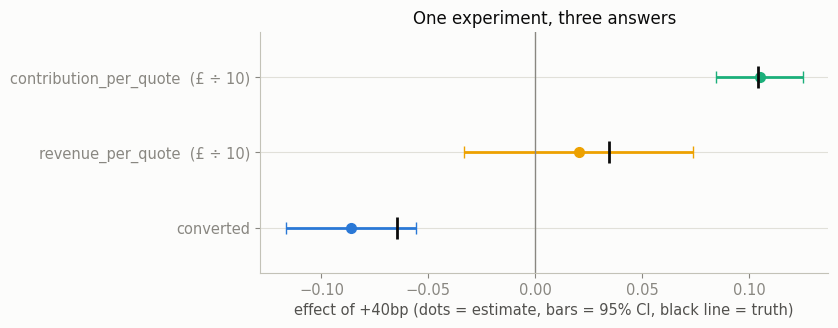

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
labels, colours = [], [PALETTE[0], PALETTE[2], PALETTE[1]]
truth_vals = [exp_truth["true_ate_conversion_pp"] / 100,
              exp_truth["true_revenue_per_quote_change_gbp"],
              exp_truth["true_contribution_per_quote_change_gbp"]]

for i, (row, truth_val) in enumerate(zip(results.itertuples(), truth_vals)):
    scale = 1.0 if row.metric == "converted" else 0.1     # put all three on one readable axis
    ax.errorbar(row.difference * scale, i, xerr=1.96 * row.se * scale, fmt="o", color=colours[i],
                capsize=4, ms=7, lw=2)
    ax.scatter(truth_val * scale, i, marker="|", s=260, color=INK, zorder=4)
    labels.append(row.metric + ("" if row.metric == "converted" else "  (£ ÷ 10)"))

ax.axvline(0, color=MUT, lw=1)
ax.set_yticks(range(3))
ax.set_yticklabels(labels)
ax.set_xlabel("effect of +40bp (dots = estimate, bars = 95% CI, black line = truth)")
ax.set_title("One experiment, three answers")
ax.set_ylim(-0.6, 2.6)
tidy(ax)
plt.tight_layout()
plt.show()

## Getting more out of the same data: variance reduction

The revenue metric failed because order values are log-normal — a handful of
£2,000-plus orders dominate the variance. Two standard fixes, neither of which
changes what the experiment *measures*, only how precisely.

**Winsorising** caps extreme values at a percentile. It trades a little bias
for a lot of variance, and you must decide the cap **before** you look at
the result (otherwise you are choosing the answer).

**Covariate adjustment** — regress the outcome on the treatment *and* on
pre-treatment variables. Any variation the covariates explain stops being
noise. This is the idea behind CUPED and it is free precision, provided the
covariates are genuinely pre-treatment.

In [6]:
cap = during["order_value_gbp"].quantile(0.99)
during["revenue_winsorised"] = np.where(during["converted"] == 1,
                                        np.minimum(during["order_value_gbp"], cap) * margin / 100, 0.0)
during["log_order"] = np.log(during["order_value_gbp"])
during["is_test"] = (during["arm"] == "test").astype(int)

plain = compare(during, "revenue_per_quote")
winsor = compare(during, "revenue_winsorised")
adjusted = smf.ols("revenue_per_quote ~ is_test + log_order + C(segment) + loyalty_member",
                   data=during).fit()

rows = [
    {"approach": "raw revenue per quote", "effect": plain["difference"], "se": plain["se"]},
    {"approach": f"winsorised at £{cap:,.0f}", "effect": winsor["difference"], "se": winsor["se"]},
    {"approach": "covariate-adjusted (OLS)", "effect": adjusted.params["is_test"],
     "se": adjusted.bse["is_test"]},
]
out = pd.DataFrame(rows)
out["95% CI"] = [f"[{r.effect - 1.96 * r.se:+.3f}, {r.effect + 1.96 * r.se:+.3f}]" for r in out.itertuples()]
out["CI width"] = (2 * 1.96 * out["se"]).round(3)
print(out.round(4).to_string(index=False))
print(f"\ntruth: {exp_truth['true_revenue_per_quote_change_gbp']:+.3f}")

                approach  effect     se           95% CI  CI width
   raw revenue per quote  0.2037 0.2731 [-0.332, +0.739]     1.070
    winsorised at £1,790  0.2347 0.2691 [-0.293, +0.762]     1.055
covariate-adjusted (OLS)  0.1572 0.2449 [-0.323, +0.637]     0.960

truth: +0.345


Both fixes tighten the interval without touching the design, and covariate
adjustment does most of the work: the standard error falls about 11%, which
— because sample size scales with the *square* of precision — is worth the
same as running the test roughly **26% longer**. Free, and decided in
advance rather than discovered afterwards.

Note what has *not* happened: the interval still comfortably contains zero.
Variance reduction buys precision, not certainty. This metric remains too
noisy to answer the question at this sample size, and the honest conclusion
is "revenue per quote: inconclusive", not "revenue rose".

## The three ways experiments go wrong

### 1. Peeking

You check the test every morning. The moment it looks significant, you stop
and declare victory. This *feels* efficient and it is statistically
disastrous: each look is another chance to cross the line by luck, so your
real false-positive rate is far above 5%.

Let's measure it, on data where the true effect is exactly zero.

In [7]:
def peeking_experiment(n_max=5000, looks=10, p=0.55, alpha=0.05):
    """An A/A test - no real effect. Does it 'win' at any interim look?"""
    a = rng.random(n_max) < p
    b = rng.random(n_max) < p
    checkpoints = np.linspace(n_max // looks, n_max, looks).astype(int)
    for n in checkpoints:
        pa, pb = a[:n].mean(), b[:n].mean()
        se = np.sqrt(pa * (1 - pa) / n + pb * (1 - pb) / n)
        if se > 0 and abs(pb - pa) / se > 1.96:
            return True
    return False


trials = 2000
false_positive_peeking = np.mean([peeking_experiment() for _ in range(trials)])
false_positive_single = np.mean([peeking_experiment(looks=1) for _ in range(trials)])

print(f"look once, at the end:      {false_positive_single:.1%} of A/A tests declared a winner")
print(f"look 10 times along the way: {false_positive_peeking:.1%} of A/A tests declared a winner")
print("\nSame data, same null hypothesis, no effect anywhere. The only difference is how often you looked.")

look once, at the end:      5.0% of A/A tests declared a winner
look 10 times along the way: 19.8% of A/A tests declared a winner

Same data, same null hypothesis, no effect anywhere. The only difference is how often you looked.


Roughly one in five null tests "wins" if you peek ten times. In an
organisation running twenty price tests a year with daily monitoring, that
manufactures several confident, celebrated, entirely imaginary results
annually — and they enter the pricing model as fact.

The defences, in order of practicality:

1. **Fix the sample size and the end date in advance**, and only look then.
2. If you must monitor, monitor **guardrails** (complaint rate, fraud, an
   outage) rather than the primary metric — those are safety stops, not
   readouts.
3. If you genuinely need to stop early, use a method designed for it:
   sequential testing (alpha spending, always-valid p-values). Never
   improvise.

### 2. Underpowering

[Lab 2.2](lab_02_statistical_foundations.ipynb)'s arithmetic, restated as a rule: **decide the minimum
detectable effect before you start.** Our test had ample power for a 7pp
conversion effect and none at all for a 2% revenue effect. Both facts were
knowable on day zero, from the traffic and the variance.

### 3. Interference (violating SUTVA)

The analysis assumes one customer's treatment does not affect another
customer's outcome. Realistic ways that breaks in pricing:

- **Cannibalisation.** Cheaper online prices pull customers out of branches;
  the branch is your control group, and you have just contaminated it.
- **Shared inventory.** Test-arm customers buy more euros, the safe empties,
  control-arm customers get refused. The arms are competing for stock.
- **Talking.** Customers compare quotes, screenshot rates, post them.
- **Competitor reaction.** If your test is big enough to move the market,
  the competitor responds — and their response hits both arms.

The fix is usually to randomise at a **coarser unit**: by branch, by region,
by week (switchback). Coarser units mean fewer independent observations and
therefore much lower power — which is exactly why geo-experiments need to
run for months.

## From a result to a decision

The experiment answers "what happened when we did this, here, then". The
decision needs three more steps.

**1. Convert the effect into annual money.** Take the measured contribution
uplift per quote, multiply by the online quotes a year on these two
products, and put it next to the group's operating profit. That single
sentence is what the meeting needs; the t-statistic is not.

**2. Ask what the test did *not* cover.** Eight weeks, one channel, two
products, a 40bp move. It says nothing about 80bp (the response may not be
linear), about branches (different customers), or about what happens after
customers habituate. The safe reading of any price test is *local*.

**3. Plan the rollout as another experiment.** Move in steps, keep a holdout
that stays at the old rate, and watch a small number of pre-agreed
guardrails. That holdout is how you catch the slow effects an eight-week
test structurally cannot see — repeat purchase, complaints, churn.

In [8]:
annual_quotes = (online[online["product_id"].isin(["EUR_CASH", "USD_CASH"])]
                 .groupby(online["date"].dt.year).size().mean())
effect = compare(during, "contribution_per_quote")

print(f"online EUR+USD quotes per year : {annual_quotes:,.0f}")
print(f"measured contribution uplift   : £{effect['difference']:.2f} per quote "
      f"(95% CI £{effect['difference'] - 1.96 * effect['se']:.2f} to £{effect['difference'] + 1.96 * effect['se']:.2f})")
print(f"annualised                     : {money(effect['difference'] * annual_quotes)} "
      f"[{money((effect['difference'] - 1.96 * effect['se']) * annual_quotes)} to "
      f"{money((effect['difference'] + 1.96 * effect['se']) * annual_quotes)}]")
print("\nPut that next to the group's operating profit for the year to see whether it matters.")

online EUR+USD quotes per year : 28,533
measured contribution uplift   : £1.05 per quote (95% CI £0.85 to £1.25)
annualised                     : £29,952 [£24,201 to £35,703]

Put that next to the group's operating profit for the year to see whether it matters.


## Practice

1. A test shows +2.1% revenue per quote, p = 0.04, after the team checked
   the dashboard every morning for six weeks. What is your read?
2. You want to test a 25bp rate change in one branch. It serves about 10
   quotes a day and converts at 55%. Roughly how long must the test run to
   detect the conversion effect you would expect (about −6% relative)? What
   would you propose instead?
3. The test above raised online contribution per quote from £0.73 to £1.82.
   Should we now raise the online rate by 80bp?

<details>
<summary>Answers</summary>

1. Treat it as **not proven**. Daily peeking over six weeks is ~40 looks, so
   the real false-positive rate is far above 5% and p = 0.04 is close to the
   line. Ask three questions: was the sample size fixed in advance; is the
   effect stable across weeks and segments; and is the effect large enough
   to matter commercially? If it survives all three, run a confirmatory test
   with a pre-registered end date. It is cheaper than being wrong.

2. Expected effect ≈ 0.55 × 6% ≈ 3pp of conversion. With p ≈ 0.5,
   n ≈ 16 × 0.25 / 0.03² ≈ 4,400 per arm — 8,800 quotes. A single branch
   sees only a handful of quotes a day, so that is **years**, not months. That is not a test, it is a research project.
   Alternatives: test a **larger** price move (a 75bp change needs roughly a
   ninth of the sample); pool whole regions and randomise by region — which
   is exactly the geo design [the omnichannel lab](../05_the_panel/lab_omnichannel_case_study.ipynb) builds; or accept a modelled answer
   from the zones' natural price variation ([lab 2.5](lab_05_causal_inference.ipynb)) and reserve
   quote-level experiments for the channel with the traffic to support
   them.

3. Not directly. The test measured one point on the curve, and a 40bp effect
   does not linearly extrapolate to 80bp — conversion losses compound as you
   move further from the competitor's rate, and at some point the segment
   mix itself changes as bargain hunters leave entirely. The disciplined
   path: bank the 40bp, then test 40 → 80 against a control that stays at
   40. [Lab 1.3](../01_set_the_rate/lab_03_price_optimisation.ipynb) shows how to combine the experiment with the demand model
   to *estimate* where the peak is — and why the flat hilltop means you
   should walk towards it rather than jump.

</details>

---

**Next:** `07_causal_inference.ipynb` — what to do about the 95% of pricing
questions you cannot randomise.